In [2]:
import pandas as pd 
import numpy as np 


#verificacao de quantidade e percentual das classes (III)

df_financas = pd.read_csv("financas_data.csv")

contagem = (df_financas["loan_status"].value_counts())
percentual = (df_financas["loan_status"].value_counts(normalize=True) * 100) 

resumo = pd.DataFrame({
    "quantidade": contagem,
    "percentual": percentual.round(2)
    
})
display(resumo)
df_financas.shape


,quantidade,percentual
loan_status,,
0,35000,77.78
1,10000,22.22


(45000, 14)

In [3]:
#separacao da base para teste e desenvolvimento (IV)

from sklearn.model_selection import train_test_split

x = df_financas.drop(columns=["loan_status"]) #colunas que o programa vai usar para prever menos a target (.drop())
y = df_financas["loan_status"] #coluna alvo isolada

x_dev, x_test, y_dev, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, )

#separacao para pré processsamento 

colunas_numericas = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
]

colunas_categoricas = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]
len(colunas_numericas), len(colunas_categoricas)


#COMENTARIOS 

#SKLEARN - biblioteca
#MODEL_SELECTION - ferramenta do sklearn para separar e avaliar dados
#TRAIN_TEST_SPLIT - dividir/separar os dados

(8, 5)

In [4]:
#pre-processamento e representacao TF-IDF para textos e One-Hot Encoding para variáveis categóricas (V)
#aqui utilizaremos One-Hot pois temos apenas variaveis categoricas e nao de texto 

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler #coloca variaveis numericas em escala comparaveis
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(handle_unknown="ignore")

preprocessador = ColumnTransformer(#objeto
    transformers=[
        ("numericas", StandardScaler(), colunas_numericas),
        ("categoricas", encoder, colunas_categoricas) #aplicar o encoder na colunas_categoricas
        
    ],
    remainder="passthrough" #nao passe pelas colunas que nao foram mencionadas
)

x_dev_preparado = preprocessador.fit_transform(x_dev) #fit_transform == aprenda as categorias e transforme em dados 
x_test_preparado = preprocessador.transform(x_test)

x_dev_preparado.shape
x_test_preparado.shape
preprocessador.get_feature_names_out()

array(['numericas__person_age', 'numericas__person_income',
       'numericas__person_emp_exp', 'numericas__loan_amnt',
       'numericas__loan_int_rate', 'numericas__loan_percent_income',
       'numericas__cb_person_cred_hist_length', 'numericas__credit_score',
       'categoricas__person_gender_female',
       'categoricas__person_gender_male',
       'categoricas__person_education_Associate',
       'categoricas__person_education_Bachelor',
       'categoricas__person_education_Doctorate',
       'categoricas__person_education_High School',
       'categoricas__person_education_Master',
       'categoricas__person_home_ownership_MORTGAGE',
       'categoricas__person_home_ownership_OTHER',
       'categoricas__person_home_ownership_OWN',
       'categoricas__person_home_ownership_RENT',
       'categoricas__loan_intent_DEBTCONSOLIDATION',
       'categoricas__loan_intent_EDUCATION',
       'categoricas__loan_intent_HOMEIMPROVEMENT',
       'categoricas__loan_intent_MEDICAL',
      

In [5]:
#montando pipeline e fazendo a validacao cruzada

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold #StratifiedKFold - fazer validacao cruzada

validacao_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo 1: Regressão Logística
pipeline_logreg = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])
parametros_logreg = {"modelo__C": [0.01, 0.1, 1, 10]}

# Modelo 2: Random Forest
pipeline_rf = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(random_state=42, n_jobs=1))
])
parametros_rf = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [5, 10, None]
}

# Modelo 3: Gradient Boosting
pipeline_gb = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", GradientBoostingClassifier(random_state=42))
])
parametros_gb = {
    "modelo__n_estimators": [100, 200],
    "modelo__learning_rate": [0.05, 0.1],
    "modelo__max_depth": [2, 3]
}

print(pipeline_logreg)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numericas', StandardScaler(),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_exp',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'credit_score']),
                                                 ('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['person_gender',
                                                   'person_education',
                     

In [ ]:
#Regressao Logostica (VI) relatorio
busca_logreg = RandomizedSearchCV(
    estimator=pipeline_logreg,
    param_distributions=parametros_logreg,
    cv=validacao_cruzada,
    scoring="average_precision",
    n_iter=4,
    random_state=42,
    n_jobs=-1
)

busca_logreg.fit(x_dev, y_dev)

print("Melhores parâmetros:")
print(busca_logreg.best_params_)

print("\nMelhor Average precision na validação (RL):")
print(busca_logreg.best_score_)

#Random Forest
busca_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=parametros_rf,
    cv=validacao_cruzada,
    scoring="average_precision",
    n_iter=6,
    random_state=42,
    n_jobs=-1
)

busca_rf.fit(x_dev, y_dev)

print("Melhores parâmetros:")
print(busca_rf.best_params_)

print("\nMelhor Average Precision na validação:")
print(busca_rf.best_score_)

#Grandient Boosting
busca_gb = RandomizedSearchCV(
    estimator=pipeline_gb,
    param_distributions=parametros_gb,
    cv=validacao_cruzada,
    scoring="average_precision",
    n_iter=8,
    random_state=42,
    n_jobs=-1
)

busca_gb.fit(x_dev, y_dev)

print("Melhores parâmetros:")
print(busca_gb.best_params_)

print("\nMelhor Average Precision na validação (GB):")
print(busca_gb.best_score_)

Melhores parâmetros:
{'modelo__C': 0.1}

Melhor Average precision na validação (RL):
0.8553679643801914
Melhores parâmetros:
{'modelo__n_estimators': 200, 'modelo__max_depth': None}

Melhor Average Precision na validação:
0.9257302139056931
Melhores parâmetros:
{'modelo__n_estimators': 200, 'modelo__max_depth': 3, 'modelo__learning_rate': 0.1}

Melhor Average Precision na validação ():
0.9297351266701502


In [ ]:
#(II) e (III)programa  / rotulos reais e probabilidades estimadas
# Melhores modelos encontrados na validação
modelo_logreg = busca_logreg.best_estimator_
modelo_rf = busca_rf.best_estimator_
modelo_gb = busca_gb.best_estimator_

# Probabilidade estimada da classe positiva (1) para cada instância do teste
prob_classe1_logreg = modelo_logreg.predict_proba(x_test)[:, 1]
prob_classe1_rf = modelo_rf.predict_proba(x_test)[:, 1]
prob_classe1_gb = modelo_gb.predict_proba(x_test)[:, 1]


resultados_prob = pd.DataFrame({
    "Rótulo real": y_test.values,
    "Prob. Logística": prob_classe1_logreg * 100,
    "Prob. Random Forest": prob_classe1_rf * 100,
    "Prob. Gradient Boosting": prob_classe1_gb * 100
})

print(resultados_prob.head(10).round(2))
y_real = y_test
print(y_real[:10])

   Rótulo real  Prob. Logística  Prob. Random Forest  Prob. Gradient Boosting
0            0             0.06                  0.0                     0.35
1            0             0.01                  0.0                     0.06
2            0             8.66                 10.0                     4.30
3            0             0.08                  0.0                     0.06
4            0             0.01                  0.0                     0.02
5            0             0.06                  0.0                     0.04
6            0             0.07                  0.0                     0.19
7            0             0.77                  0.0                     0.17
8            0            18.48                 13.5                     8.56
9            1            87.35                100.0                    98.41
16368    0
38303    0
34202    0
19514    0
6252     0
36581    0
39724    0
33960    0
23741    0
17563    1
Name: loan_status, dtype: int64


In [8]:
import numpy as np

#converter probabilidades para LOGIT 
LIMIAR = 6.9068

def para_logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

y_true = np.array(y_test)

scores = {
    "Regressão Logística": para_logit(prob_classe1_logreg),
    "Random Forest":       para_logit(prob_classe1_rf),
    "Gradient Boosting":   para_logit(prob_classe1_gb),
}


In [9]:
#Avaliacao dos modelos / calcular metricas / tabela comparativa(VII) - relatorio'

import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, auc,
                             average_precision_score, confusion_matrix)
                             

linhas = []
for nome, s in scores.items():
    y_pred = (s >= LIMIAR).astype(int)
    prec_c, rec_c, _ = precision_recall_curve(y_true, s)
    linhas.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, s),
        "AUC-PR (trapezoidal)": auc(rec_c, prec_c),
        "AP (Average Precision)": average_precision_score(y_true, s),
    })

tabela = pd.DataFrame(linhas).set_index("Modelo").round(4)
print(tabela)

                     Acurácia  Precisão  Recall  F1-score  AUC-ROC  \
Modelo                                                               
Regressão Logística    0.7778       0.0  0.0000    0.0000   0.9554   
Random Forest          0.7864       1.0  0.0390    0.0751   0.9750   
Gradient Boosting      0.7814       1.0  0.0165    0.0325   0.9765   

                     AUC-PR (trapezoidal)  AP (Average Precision)  
Modelo                                                             
Regressão Logística                0.8563                  0.8564  
Random Forest                      0.9320                  0.9313  
Gradient Boosting                  0.9358                  0.9358  


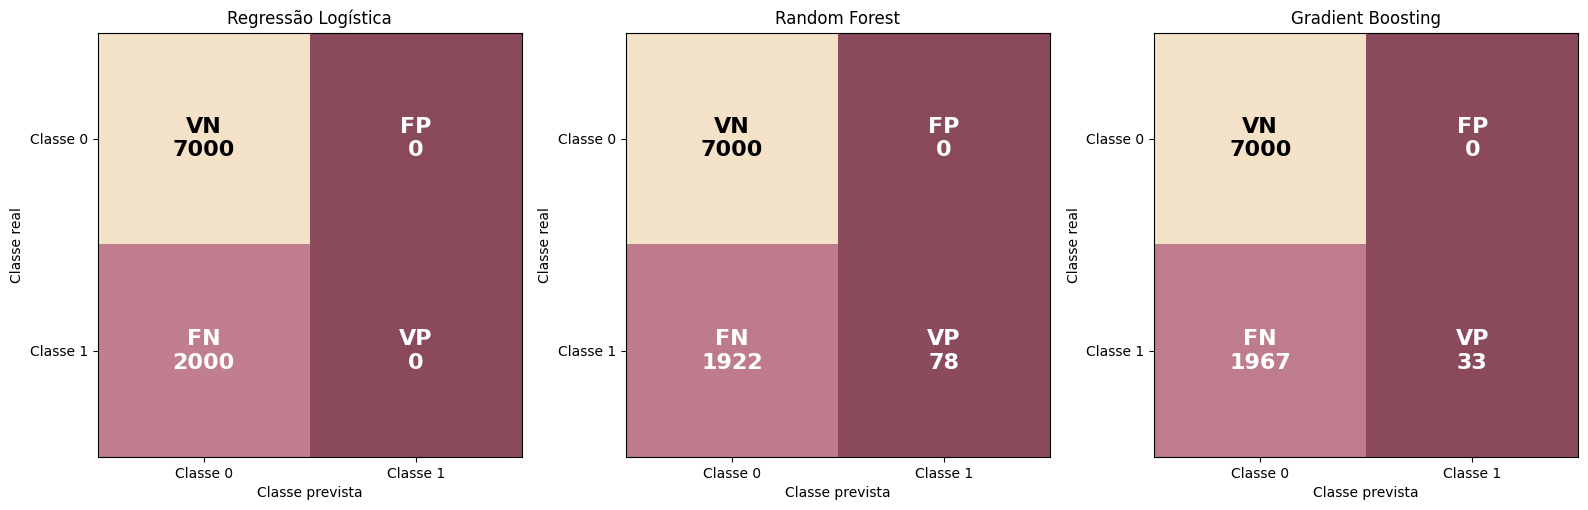

In [17]:
# matriz de confusao 

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix

# escala: rosa escuro (números pequenos) -> rosa -> bege (números grandes)
rosa_bege = LinearSegmentedColormap.from_list(
    "rosa_bege", ["#8b4a5c", "#e8a5b5", "#f3e2c7"]
)

siglas = np.array([["VN", "FP"],
                   ["FN", "VP"]])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nome, s) in zip(axes, scores.items()):
    y_pred = (s >= LIMIAR).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    ax.imshow(cm, cmap=rosa_bege)

    for i in range(2):
        for j in range(2):
            # fundo escuro (número pequeno) -> texto branco; fundo claro -> texto preto
            cor = "white" if cm[i, j] < cm.max() * 0.3 else "black"
            ax.text(j, i, f"{siglas[i, j]}\n{cm[i, j]}",
                    ha="center", va="center", fontsize=16,
                    fontweight="bold", color=cor)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Classe 0", "Classe 1"])
    ax.set_yticklabels(["Classe 0", "Classe 1"])
    ax.set_xlabel("Classe prevista")
    ax.set_ylabel("Classe real")
    ax.set_title(nome)

plt.tight_layout()
plt.show()

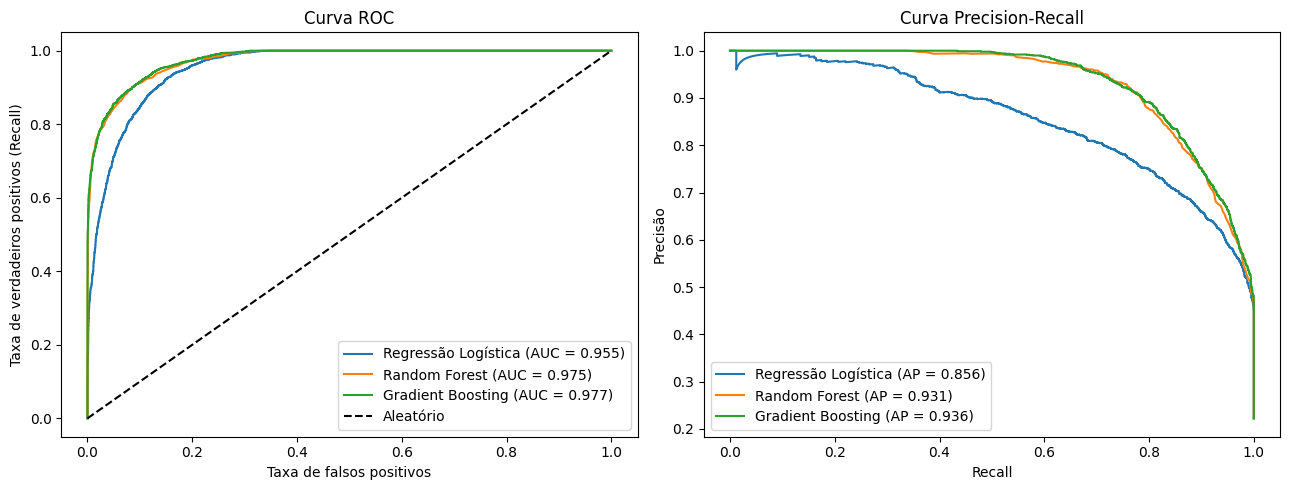

In [11]:
# curva ROC e PR (Precision-Recall) (VIII) - relatorio'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for nome, s in scores.items():
    fpr, tpr, _ = roc_curve(y_true, s)
    axes[0].plot(fpr, tpr, label=f"{nome} (AUC = {auc(fpr, tpr):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Aleatório")
axes[0].set_xlabel("Taxa de falsos positivos")
axes[0].set_ylabel("Taxa de verdadeiros positivos (Recall)")
axes[0].set_title("Curva ROC")
axes[0].legend()

for nome, s in scores.items():
    p, r, _ = precision_recall_curve(y_true, s)
    axes[1].plot(r, p, label=f"{nome} (AP = {average_precision_score(y_true, s):.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisão")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()

plt.tight_layout()
plt.show()

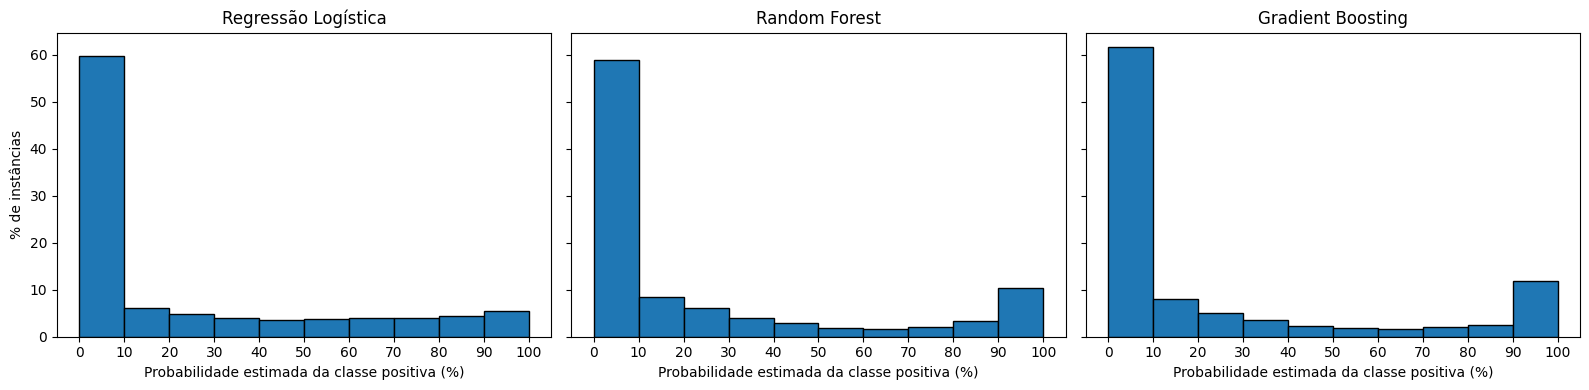

In [12]:
# histograma das probabilidades (IV) - programa'

bins = np.arange(0, 101, 10)
probs = {
    "Regressão Logística": prob_classe1_logreg * 100,
    "Random Forest":       prob_classe1_rf * 100,
    "Gradient Boosting":   prob_classe1_gb * 100,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (nome, p) in zip(axes, probs.items()):
    pesos = np.ones(len(p)) / len(p) * 100
    ax.hist(p, bins=bins, weights=pesos, edgecolor="black")
    ax.set_title(nome)
    ax.set_xlabel("Probabilidade estimada da classe positiva (%)")
    ax.set_xticks(bins)
axes[0].set_ylabel("% de instâncias")
plt.tight_layout()
plt.show()